In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("../../data/fifa_world_cup_2026_player_performance.csv"); df["match_date"]=pd.to_datetime(df["match_date"],errors="coerce")
print("FIFA dataset loaded successfully"); print("Shape:",df.shape); display(df.head())

FIFA dataset loaded successfully
Shape: (54600, 75)


,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,club_name,market_value_eur,match_id,match_date,stadium,city,opponent_team,tournament_stage,match_result,goals_team,goals_opponent,minutes_played,goals,assists,shots,shots_on_target,expected_goals_xg,expected_assists_xa,key_passes,successful_passes,total_passes,pass_accuracy,dribbles_attempted,successful_dribbles,crosses,successful_crosses,tackles,interceptions,clearances,blocks,aerial_duels_won,aerial_duels_lost,recoveries,defensive_actions,fouls_committed,fouls_suffered,yellow_cards,red_cards,offsides,saves,save_percentage,punches,clean_sheet,goals_conceded,penalty_saves,distance_covered_km,sprint_distance_km,top_speed_kmh,accelerations,decelerations,stamina_score,player_rating,performance_score,offensive_contribution,defensive_contribution,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,RB Salzburg,4384884,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,72,0,0,0,0,0.00,0.00,0,15,26,0.59,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,4,0.83,0,1,0,0,7.8,0.7,26.5,13,23,81.9,5.6,50.9,3.3,48.2,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,Chelsea,4918927,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,90,0,0,0,0,0.01,0.00,1,35,40,0.89,1,0,1,0,0,1,3,1,2,0,2,5,0,1,0,0,0,0,0.00,0,0,0,0,10.4,1.1,29.0,19,17,85.5,5.7,55.9,37.9,29.4,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,AIK,125015698,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,73,1,0,2,0,0.08,0.07,2,72,85,0.85,0,0,3,0,1,1,0,0,1,2,4,2,0,0,0,0,0,0,0.00,0,0,0,0,8.8,1.3,33.7,30,19,88.8,8.3,82.9,79.8,78.6,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,PSV Eindhoven,11805512,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,80,1,1,5,2,0.00,0.21,0,12,19,0.67,1,0,0,0,1,1,1,0,3,0,1,3,0,1,0,0,0,0,0.00,0,0,0,0,9.6,1.0,32.1,26,19,89.2,6.9,67.5,47.3,6.9,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,Juventus,13325174,M00001,2026-07-10,Hard Rock Stadium,Miami,South Africa,Group Stage,W,1,0,79,0,0,1,0,0.00,0.00,1,33,44,0.76,2,1,0,0,1,3,0,2,1,2,4,6,0,0,0,0,0,0,0.00,0,0,0,0,7.5,0.7,30.5,23,18,73.6,5.7,55.4,33.0,75.6,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [2]:
print("Column names:"); print(df.columns.tolist()); print("\nData types:"); print(df.dtypes)

Column names:
['player_id', 'player_name', 'age', 'nationality', 'team', 'jersey_number', 'position', 'height_cm', 'weight_kg', 'preferred_foot', 'club_name', 'market_value_eur', 'match_id', 'match_date', 'stadium', 'city', 'opponent_team', 'tournament_stage', 'match_result', 'goals_team', 'goals_opponent', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'expected_goals_xg', 'expected_assists_xa', 'key_passes', 'successful_passes', 'total_passes', 'pass_accuracy', 'dribbles_attempted', 'successful_dribbles', 'crosses', 'successful_crosses', 'tackles', 'interceptions', 'clearances', 'blocks', 'aerial_duels_won', 'aerial_duels_lost', 'recoveries', 'defensive_actions', 'fouls_committed', 'fouls_suffered', 'yellow_cards', 'red_cards', 'offsides', 'saves', 'save_percentage', 'punches', 'clean_sheet', 'goals_conceded', 'penalty_saves', 'distance_covered_km', 'sprint_distance_km', 'top_speed_kmh', 'accelerations', 'decelerations', 'stamina_score', 'player_rating', 'performan

In [3]:
print("Statistical summary:"); display(df[["age","minutes_played","goals","assists","shots","player_rating"]].describe().round(2))

Statistical summary:


,age,minutes_played,goals,assists,shots,player_rating
count,54600.00,54600.00,54600.00,54600.00,54600.00,54600.00
mean,26.30,36.20,0.06,0.05,0.45,3.63
std,4.07,36.42,0.25,0.24,0.95,3.16
min,17.00,0.00,0.00,0.00,0.00,0.00
25%,23.00,0.00,0.00,0.00,0.00,0.00
50%,26.00,24.00,0.00,0.00,0.00,5.50
75%,29.00,75.00,0.00,0.00,1.00,6.40
max,39.00,90.00,4.00,3.00,11.00,9.40


In [4]:
filtered=df[(df["tournament_stage"]=="Knockout Stage")&(df["player_rating"]>=8)]; print("Knockout-stage records with rating 8 or above:"); display(filtered[["player_name","team","position","player_rating","goals","assists"]].head(10))

Knockout-stage records with rating 8 or above:


,player_name,team,position,player_rating,goals,assists


In [5]:
print("Top teams by total goals:"); display(df.groupby("team")["goals"].sum().sort_values(ascending=False).head(10))

Top teams by total goals:


team
Qatar           95
Netherlands     94
Panama          90
Cameroon        88
Saudi Arabia    82
Jamaica         79
Tunisia         78
Costa Rica      76
Ghana           75
Iran            72
Name: goals, dtype: int64

In [6]:
print("Stage-wise total goals:"); display(df.groupby("tournament_stage")["goals"].sum())

Stage-wise total goals:


tournament_stage
Final                  62
Group Stage          1630
Quarter Finals        245
Round of 16           364
Round of 32           532
Semi Finals           134
Third Place Match      57
Name: goals, dtype: int64

In [7]:
print("Correlation matrix:"); display(df[["age","minutes_played","goals","assists","shots","player_rating"]].corr().round(2))

Correlation matrix:


,age,minutes_played,goals,assists,shots,player_rating
age,1.00,-0.02,-0.04,-0.03,-0.07,-0.04
minutes_played,-0.02,1.00,0.22,0.22,0.47,0.84
goals,-0.04,0.22,1.00,0.09,0.27,0.22
assists,-0.03,0.22,0.09,1.00,0.19,0.20
shots,-0.07,0.47,0.27,0.19,1.00,0.42
player_rating,-0.04,0.84,0.22,0.20,0.42,1.00


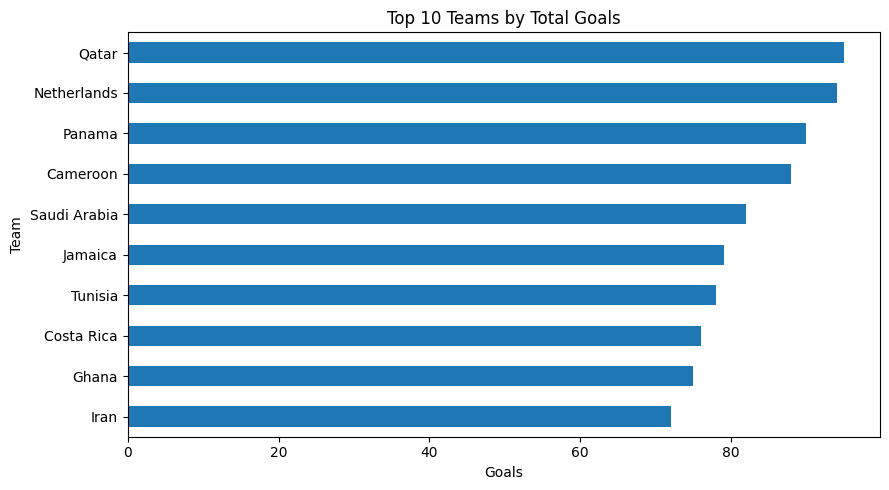

In [8]:
plt.figure(figsize=(9,5)); df.groupby("team")["goals"].sum().nlargest(10).sort_values().plot(kind="barh"); plt.title("Top 10 Teams by Total Goals"); plt.xlabel("Goals"); plt.ylabel("Team"); plt.tight_layout(); plt.show()

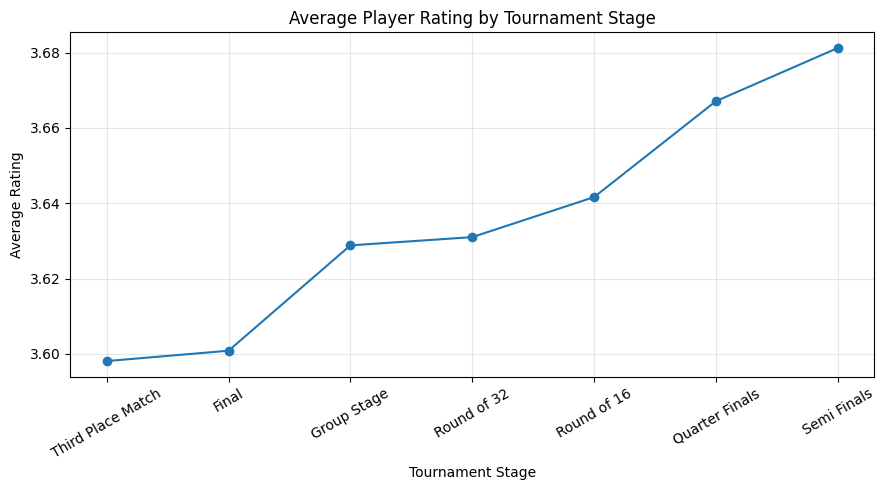

In [9]:
stage_rating=df.groupby("tournament_stage")["player_rating"].mean().sort_values(); plt.figure(figsize=(9,5)); plt.plot(stage_rating.index,stage_rating.values,marker="o"); plt.title("Average Player Rating by Tournament Stage"); plt.xlabel("Tournament Stage"); plt.ylabel("Average Rating"); plt.xticks(rotation=30); plt.grid(True,alpha=.3); plt.tight_layout(); plt.show()